# Imports

In [1]:
import tacco as tc
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pickle

/athena/cayuga_0039/scratch/mke4001/miniforge3/envs/spatialtranscriptomics_analysis/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/athena/cayuga_0039/scratch/mke4001/miniforge3/envs/spatialtranscriptomics_analysis/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/athena/cayuga_0039/scratch/mke4001/miniforge3/envs/spatialtranscriptomics_analysis/lib/python3.12/site-packages/anndata/__init__

In [12]:
sc.set_figure_params(vector_friendly=True, dpi=50)
plt.rcParams['figure.dpi'] = 50

# Load data

In [3]:
out_dir = '/athena/cayuga_0039/scratch/mke4001/Vardhana_project/Analysis/'
fig_prefix_slideA='/athena/cayuga_0039/scratch/mke4001/Vardhana_project/Analysis/Figures4/LymphomaSlideA/LymphomaSlideA_'
fig_prefix_healthy='/athena/cayuga_0039/scratch/mke4001/Vardhana_project/Analysis/Figures4/HealthyHumanLN10X/HealthyHumanLN10X_'

In [4]:
filename_slideA=out_dir+'visiumHD_SV-3627_A_008um_TACCOannotated_pickle.obj'
filename_healthy=out_dir+'Visium_HD_Human_Lymph_Node_FFPE_008um_TACCOannotated_pickle.obj'

In [5]:
with open(filename_slideA,"rb") as f:
    adata_slideA_8um= pickle.load(f)
print('loaded slide A')
with open(filename_healthy,"rb") as f: 
    adata_healthy_8um= pickle.load(f)
print('loaded healthy slide')

loaded slide A
loaded healthy slide


# Figures

## Figure 5H

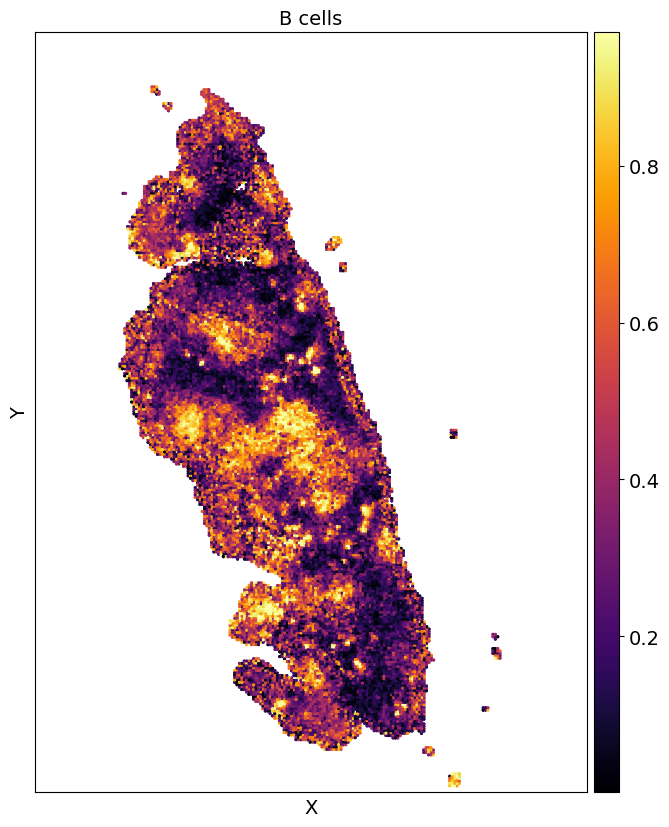

In [14]:
fig, ax = plt.subplots(figsize=(8,10))
vmax = adata_slideA_8um.obs['B_TACCOcytotoxicmerged'].quantile(q=0.99)
sq.pl.spatial_scatter(adata_slideA_8um, shape=None,color=["B_TACCOcytotoxicmerged"], title ='B cells', vmax = vmax, ax = ax, axis_label = ['X','Y'], cmap = 'inferno')
ax.set_xlim((14000,22000))
ax.set_ylim((2500,13500))
ax.invert_yaxis()
#plt.savefig(fig_prefix_slideA+'TACCO_CompositionalAnnotationHeatmap_B.pdf',bbox_inches='tight')
#plt.close()
plt.show()

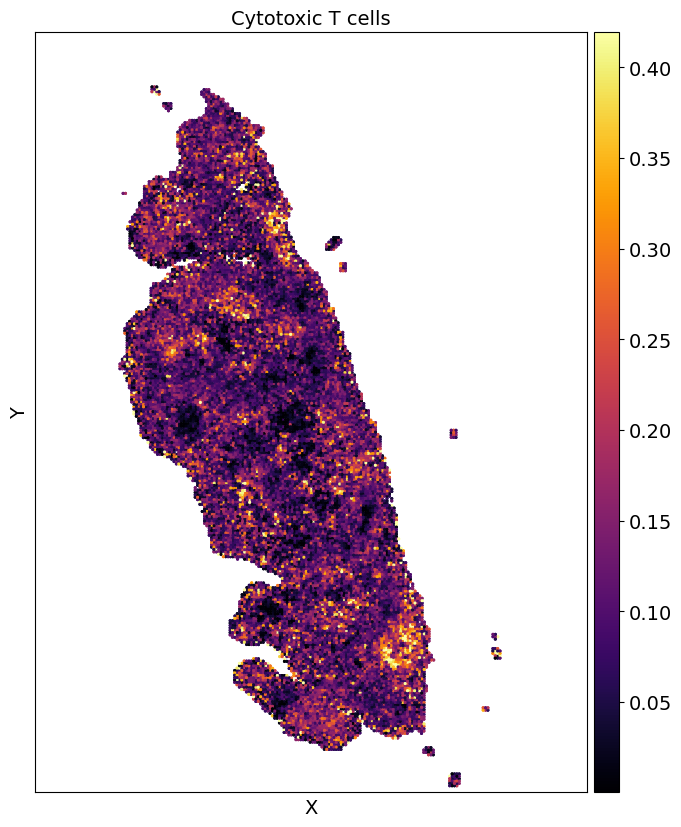

In [15]:
fig, ax = plt.subplots(figsize=(8,10))
vmax = adata_slideA_8um.obs['Cytotoxic_TACCOcytotoxicmerged'].quantile(q=0.99)
sq.pl.spatial_scatter(adata_slideA_8um, shape=None,color="Cytotoxic_TACCOcytotoxicmerged",title ='Cytotoxic T cells', vmax = vmax, cmap = 'inferno',ax = ax, axis_label = ['X','Y'])
ax.set_xlim((14000,22000))
ax.set_ylim((2500,13500))
ax.invert_yaxis()
#plt.savefig(fig_prefix_slideA+'TACCO_CompositionalAnnotationHeatmap_Cytotoxic.pdf',bbox_inches='tight')
#plt.close()
plt.show()

## Figure 5I

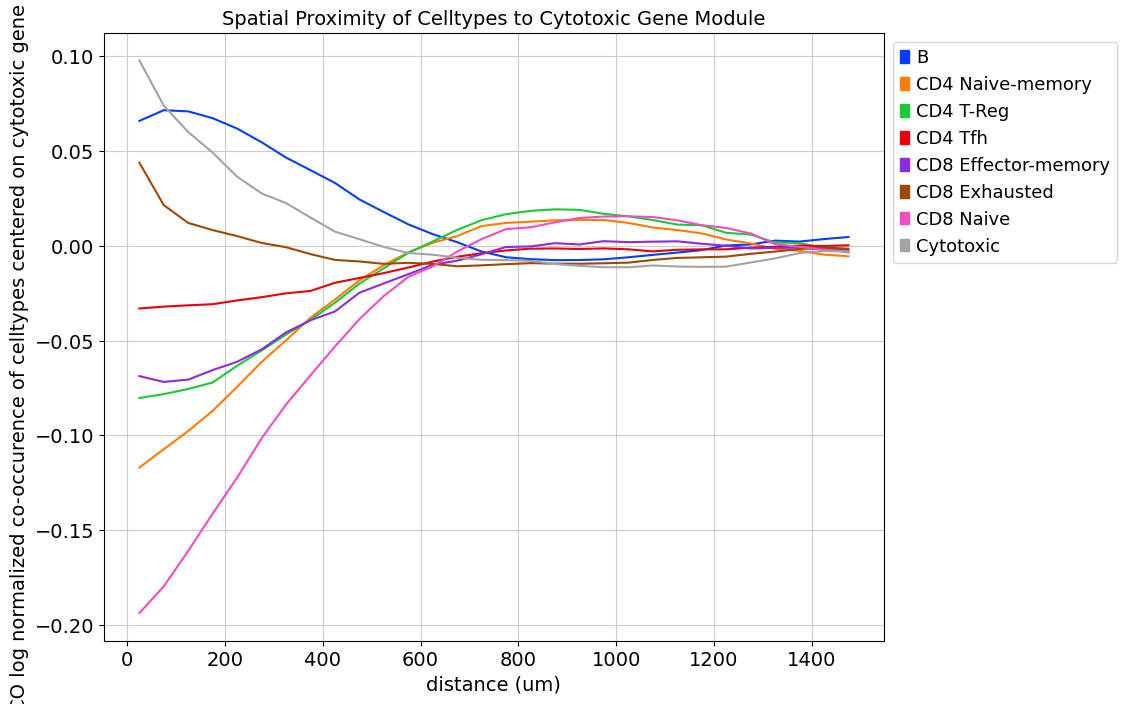

In [16]:
fig_cytotoxicscore_cooccurence, ax_cytotoxicscore_cooccurence = plt.subplots(figsize=(10,8))
tc.pl.co_occurrence(adata_slideA_8um, 'TACCOcytotoxicmerged-marker_internal', score_key='log_occ', log_base=2, wspace=0.25, show_only_center = 'cytotoxic_score', ax = ax_cytotoxicscore_cooccurence )
ax_cytotoxicscore_cooccurence.set_title('Spatial Proximity of Celltypes to Cytotoxic Gene Module')
ax_cytotoxicscore_cooccurence.set_ylabel('TACCO log normalized co-occurence of celltypes centered on cytotoxic gene module')
ax_cytotoxicscore_cooccurence.set_xlabel('distance (um)')
#plt.savefig(fig_prefix_slideA+'TACCO_CoOccurrence_CytotoxicGeneModuleCentered.pdf',bbox_inches='tight')
#plt.close()
plt.show()

## Figure 5J

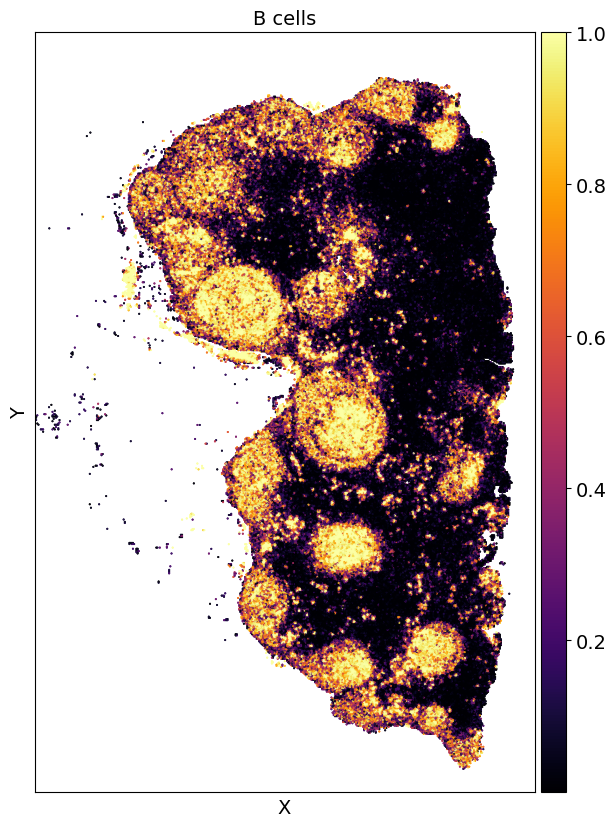

In [17]:
fig, ax = plt.subplots(figsize=(8,10))
vmax = adata_healthy_8um.obs['B_TACCOcytotoxicmerged'].quantile(q=0.99)
sq.pl.spatial_scatter(adata_healthy_8um, shape=None,color=["B_TACCOcytotoxicmerged"], title ='B cells', vmax = vmax, ax = ax, axis_label = ['X','Y'],cmap='inferno')
ax.set_xlim((2500,15000))
ax.set_ylim((1000,20000))
ax.invert_yaxis()
#plt.savefig(fig_prefix_healthy+'TACCO_CompositionalAnnotationHeatmap_B.pdf',bbox_inches='tight')
#plt.close()
plt.show()

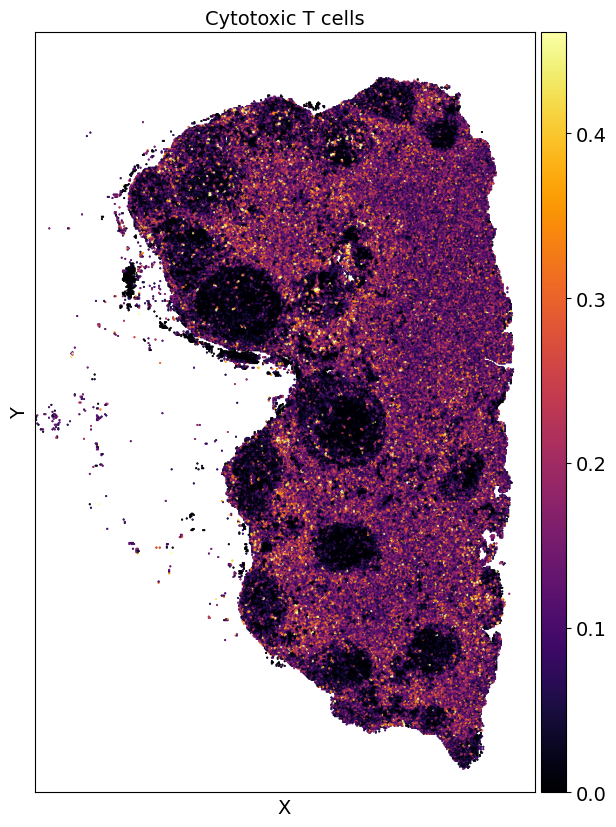

In [18]:
fig, ax = plt.subplots(figsize=(8,10))
vmax = adata_healthy_8um.obs['Cytotoxic_TACCOcytotoxicmerged'].quantile(q=0.99)
sq.pl.spatial_scatter(adata_healthy_8um, shape=None,color="Cytotoxic_TACCOcytotoxicmerged",title ='Cytotoxic T cells', vmax = vmax, ax = ax, axis_label = ['X','Y'],cmap='inferno')
ax.set_xlim((2500,15000))
ax.set_ylim((1000,20000))
ax.invert_yaxis()
#plt.savefig(fig_prefix_healthy+'TACCO_CompositionalAnnotationHeatmap_Cytotoxic.pdf',bbox_inches='tight')
#plt.close()
plt.show()

## Figure 5K

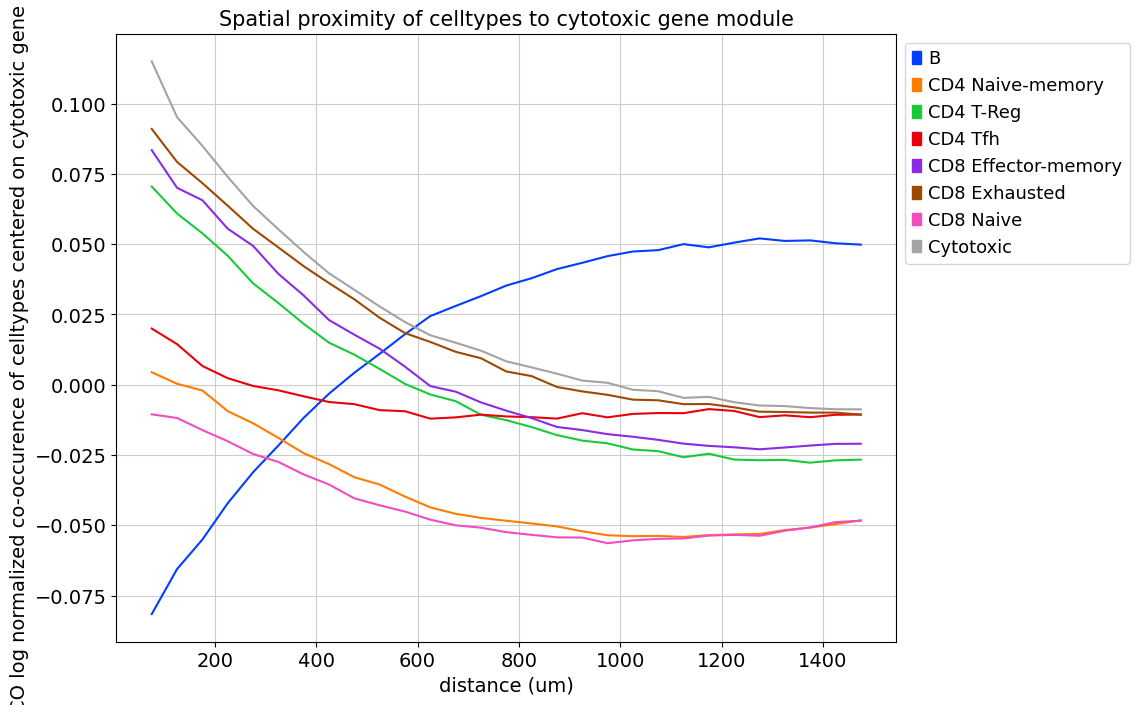

In [19]:
fig_cytotoxicscore_cooccurence, ax_cytotoxicscore_cooccurence = plt.subplots(figsize=(10,8))
tc.pl.co_occurrence(adata_healthy_8um, 'TACCOcytotoxicmerged-marker_internal', score_key='log_occ', log_base=2, wspace=0.25, show_only_center = 'cytotoxic_score', ax = ax_cytotoxicscore_cooccurence )
ax_cytotoxicscore_cooccurence.set_title('Spatial proximity of celltypes to cytotoxic gene module', fontsize=15)
ax_cytotoxicscore_cooccurence.set_ylabel('TACCO log normalized co-occurence of celltypes centered on cytotoxic gene module')
ax_cytotoxicscore_cooccurence.set_xlabel('distance (um)')
#plt.savefig(fig_prefix_healthy+'TACCO_CoOccurrence_CytotoxicGeneModuleCentered.pdf',bbox_inches='tight')
#plt.close()
plt.show()